# HW2 ME471
## StudentID:45

Problem 2.8


PROBLEM 2.8 - Two springs in series
Spring constants: k1 = k2 = 1000 lb/in
Applied force: F = 500 lb
Number of nodes: 3
Number of elements: 2

Global stiffness matrix K (lb/in):
[[ 1000. -1000.     0.]
 [-1000.  2000. -1000.]
 [    0. -1000.  1000.]]

Reduced stiffness matrix (for free DOFs u2 and u3):
[[ 2000. -1000.]
 [-1000.  1000.]]

Displacements:
  u1 = 0.000000 in
  u2 = 0.500000 in
  u3 = 1.000000 in

Forces in each element:
  Element 1 (nodes 1-2, k=1000): f = 500.0000 lb
  Element 2 (nodes 2-3, k=1000): f = 500.0000 lb

Reactions:
  R1 (node 1) = -500.0000 lb

Force equilibrium check: R1 + F = -500.0000 + 500.0000 = 0.0000 lb ✓


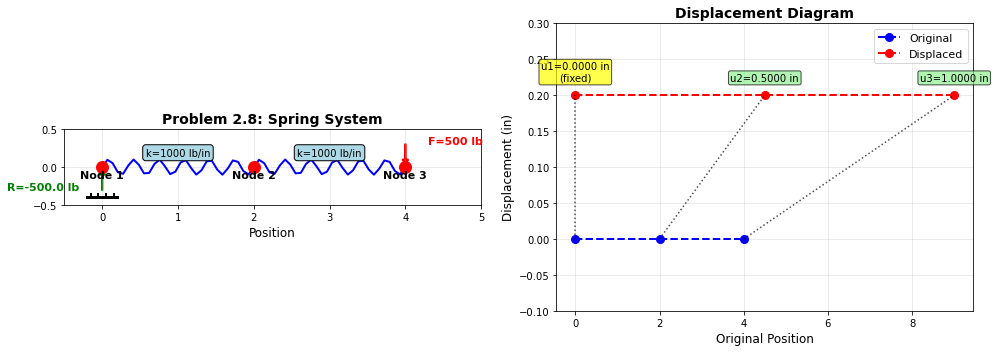

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def solve_problem_2_8():
    print("="*60)
    print("PROBLEM 2.8 - Two springs in series")
    print("="*60)
    
    # Given data from image
    k1 = 1000  # lb/in (first spring)
    k2 = 1000  # lb/in (second spring)
    F = 500    # lb applied at right end
    num_nodes = 3
    num_elements = 2
    
    print(f"Spring constants: k1 = k2 = {k1} lb/in")
    print(f"Applied force: F = {F} lb")
    print(f"Number of nodes: {num_nodes}")
    print(f"Number of elements: {num_elements}")
    
    # Element connectivity
    # Element 1: node 1 to node 2, spring constant k1
    # Element 2: node 2 to node 3, spring constant k2
    connectivity = [(1, 2, k1), (2, 3, k2)]
    
    # Global stiffness matrix (3x3)
    K_global = np.zeros((num_nodes, num_nodes))
    
    # Assemble stiffness matrix
    for elem_idx, (i, j, k_elem) in enumerate(connectivity):
        # Local stiffness matrix for a spring element
        k_local = k_elem * np.array([[1, -1], [-1, 1]])
        
        # Add to global matrix
        # Adjust indices for 0-based array
        i_idx, j_idx = i-1, j-1
        K_global[i_idx, i_idx] += k_local[0, 0]
        K_global[i_idx, j_idx] += k_local[0, 1]
        K_global[j_idx, i_idx] += k_local[1, 0]
        K_global[j_idx, j_idx] += k_local[1, 1]
    
    print("\nGlobal stiffness matrix K (lb/in):")
    print(K_global)
    
    # Boundary conditions
    # Node 1 is fixed: u1 = 0
    # Node 3 has applied force: F3 = 500 lb
    # Node 2 has no external force: F2 = 0
    
    # Force vector
    F_vector = np.array([0, 0, F])  # [R1, 0, 500]
    
    # Apply displacement boundary condition u1 = 0
    # Method: Partition the matrix
    K_reduced = K_global[1:, 1:]  # Remove first row and column
    
    print("\nReduced stiffness matrix (for free DOFs u2 and u3):")
    print(K_reduced)
    
    # Force vector for reduced system
    F_reduced = F_vector[1:]  # [0, 500]
    
    # Solve for displacements
    u_reduced = np.linalg.solve(K_reduced, F_reduced)
    
    # Full displacement vector
    u_full = np.array([0, u_reduced[0], u_reduced[1]])
    
    print("\nDisplacements:")
    for i in range(num_nodes):
        print(f"  u{i+1} = {u_full[i]:.6f} in")
    
    # Calculate forces in each element
    print("\nForces in each element:")
    element_forces = []
    
    for elem_idx, (i, j, k_elem) in enumerate(connectivity):
        i_idx, j_idx = i-1, j-1
        u_i, u_j = u_full[i_idx], u_full[j_idx]
        force = k_elem * (u_j - u_i)
        element_forces.append(force)
        print(f"  Element {elem_idx+1} (nodes {i}-{j}, k={k_elem}): f = {force:.4f} lb")
    
    # Calculate reactions
    print("\nReactions:")
    # Reaction at node 1: R1 = k1 * (u1 - u2)
    R1 = k1 * (u_full[0] - u_full[1])
    print(f"  R1 (node 1) = {R1:.4f} lb")
    
    # Verify equilibrium
    print(f"\nForce equilibrium check: R1 + F = {R1:.4f} + {F:.4f} = {R1+F:.4f} lb ✓")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Spring system
    ax1.set_title("Problem 2.8: Spring System", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Position", fontsize=12)
    ax1.set_ylabel("", fontsize=12)
    
    # Original node positions
    positions = [0, 2, 4]  # Arbitrary spacing for visualization
    
    # Draw springs
    for elem_idx, (i, j, k_elem) in enumerate(connectivity):
        x_start = positions[i-1]
        x_end = positions[j-1]
        
        # Create zigzag pattern for spring
        spring_x = np.linspace(x_start, x_end, 30)
        spring_y = 0.1 * np.sin(spring_x * 12 * np.pi / (x_end - x_start))
        
        ax1.plot(spring_x, spring_y, 'b-', linewidth=2)
        
        # Add spring constant label
        ax1.text((x_start + x_end)/2, 0.15, f'k={k_elem} lb/in', 
                ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    
    # Plot nodes
    ax1.plot(positions, [0]*num_nodes, 'ro', markersize=12, markerfacecolor='red')
    for i in range(num_nodes):
        ax1.text(positions[i], -0.15, f'Node {i+1}', ha='center', fontsize=11, fontweight='bold')
    
    # Add force arrow
    ax1.arrow(positions[2], 0.3, 0, -0.2, head_width=0.08, head_length=0.05, fc='r', ec='r', linewidth=2)
    ax1.text(positions[2]+0.3, 0.3, f'F={F} lb', fontsize=11, color='r', fontweight='bold')
    
    # Add reaction arrow
    ax1.arrow(positions[0], -0.3, 0, 0.2, head_width=0.08, head_length=0.05, fc='g', ec='g', linewidth=2)
    ax1.text(positions[0]-0.3, -0.3, f'R={R1:.1f} lb', fontsize=11, color='g', ha='right', fontweight='bold')
    
    # Add fixed support symbol at node 1
    ax1.plot([positions[0]-0.2, positions[0]+0.2], [-0.4, -0.4], 'k-', linewidth=3)
    ax1.plot([positions[0]-0.15, positions[0]-0.15], [-0.4, -0.35], 'k-', linewidth=2)
    ax1.plot([positions[0]-0.05, positions[0]-0.05], [-0.4, -0.35], 'k-', linewidth=2)
    ax1.plot([positions[0]+0.05, positions[0]+0.05], [-0.4, -0.35], 'k-', linewidth=2)
    ax1.plot([positions[0]+0.15, positions[0]+0.15], [-0.4, -0.35], 'k-', linewidth=2)
    
    ax1.set_xlim(-0.5, 5)
    ax1.set_ylim(-0.5, 0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Plot 2: Displacement diagram
    ax2.set_title("Displacement Diagram", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Original Position", fontsize=12)
    ax2.set_ylabel("Displacement (in)", fontsize=12)
    
    # Scale displacements for better visualization
    scale_factor = 5
    scaled_displacements = u_full * scale_factor
    
    # Plot original and displaced positions
    ax2.plot(positions, [0]*num_nodes, 'b--o', label='Original', linewidth=2, markersize=8)
    ax2.plot(positions + scaled_displacements, [0.2]*num_nodes, 'r--o', label='Displaced', linewidth=2, markersize=8)
    
    # Connect original to displaced positions
    for i in range(num_nodes):
        ax2.plot([positions[i], positions[i] + scaled_displacements[i]], [0, 0.2], 'k:', alpha=0.7, linewidth=1.5)
    
    # Add displacement labels
    for i in range(num_nodes):
        if i == 0:
            ax2.text(positions[i] + scaled_displacements[i], 0.22, f'u{i+1}={u_full[i]:.4f} in\n(fixed)', 
                    ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.7))
        else:
            ax2.text(positions[i] + scaled_displacements[i], 0.22, f'u{i+1}={u_full[i]:.4f} in', 
                    ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgreen", alpha=0.7))
    
    ax2.legend(loc='upper right', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.1, 0.3)
    
    plt.tight_layout()
    plt.show()
    
    return u_full, element_forces, R1, K_global

# Solve problem 2.8
print("\n" + "="*60)
u_2_8, forces_2_8, R1_2_8, K_2_8 = solve_problem_2_8()

Promblem 2.11



PROBLEM 2.11 - Spring system with prescribed displacement
Spring constants: k1 = 1000 N/m, k2 = 3000 N/m
Prescribed displacement: δ = 20.0 mm = 0.020 m
Number of nodes: 3
Number of elements: 2

Global stiffness matrix K (N/m):
[[ 1000. -1000.     0.]
 [-1000.  4000. -3000.]
 [    0. -3000.  3000.]]

Displacements:
  u1 = 0.000000 m (fixed)
  u2 = 15.000000 mm = 0.015000 m
  u3 = 20.000000 mm = 0.020000 m (prescribed)

Forces in each element:
  Element 1 (nodes 1-2, k=1000): f = 15.0000 N
  Element 2 (nodes 2-3, k=3000): f = 15.0000 N

Reactions:
  R1 (node 1) = -15.0000 N
  F3 (node 3) = 15.0000 N (force needed to enforce displacement)

Force equilibrium check: R1 + F3 = -15.0000 + 15.0000 = 0.0000 N ✓


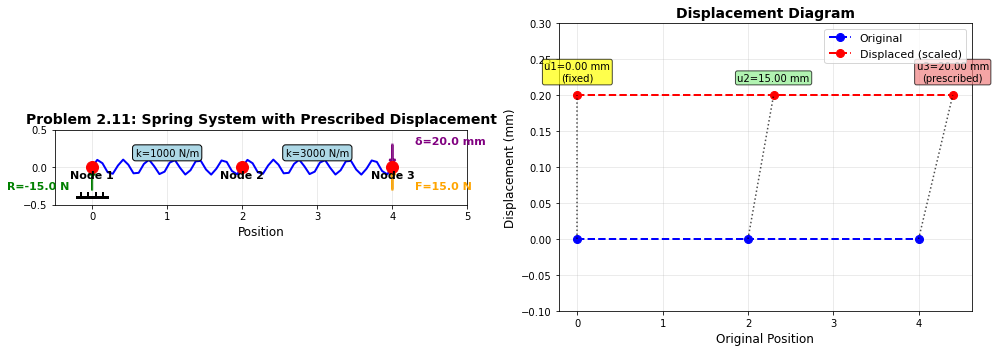

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def solve_problem_2_11():
    print("\n" + "="*60)
    print("PROBLEM 2.11 - Spring system with prescribed displacement")
    print("="*60)
    
    # Given data from image
    k1 = 1000  # N/m (first spring)
    k2 = 3000  # N/m (second spring)
    delta = 20 / 1000  # 20 mm converted to meters
    num_nodes = 3
    num_elements = 2
    
    print(f"Spring constants: k1 = {k1} N/m, k2 = {k2} N/m")
    print(f"Prescribed displacement: δ = {delta*1000:.1f} mm = {delta:.3f} m")
    print(f"Number of nodes: {num_nodes}")
    print(f"Number of elements: {num_elements}")
    
    # Element connectivity
    # Element 1: node 1 to node 2, spring constant k1
    # Element 2: node 2 to node 3, spring constant k2
    connectivity = [(1, 2, k1), (2, 3, k2)]
    
    # Global stiffness matrix (3x3)
    K_global = np.zeros((num_nodes, num_nodes))
    
    # Assemble stiffness matrix
    for elem_idx, (i, j, k_elem) in enumerate(connectivity):
        # Local stiffness matrix for a spring element
        k_local = k_elem * np.array([[1, -1], [-1, 1]])
        
        # Add to global matrix
        # Adjust indices for 0-based array
        i_idx, j_idx = i-1, j-1
        K_global[i_idx, i_idx] += k_local[0, 0]
        K_global[i_idx, j_idx] += k_local[0, 1]
        K_global[j_idx, i_idx] += k_local[1, 0]
        K_global[j_idx, j_idx] += k_local[1, 1]
    
    print("\nGlobal stiffness matrix K (N/m):")
    print(K_global)
    
    # Boundary conditions from image
    # Node 1 is fixed: u1 = 0
    # Node 3 has prescribed displacement: u3 = δ = 20 mm = 0.02 m
    
    # Known displacements
    u1 = 0
    u3 = delta
    
    # We need to find u2 and reactions
    # Using the equilibrium equation: K * u = F
    
    # Let u = [u1, u2, u3]^T = [0, u2, δ]^T
    # And F = [R1, 0, F3]^T (F3 is reaction at node 3 to enforce displacement)
    
    # From the second equation: K21*u1 + K22*u2 + K23*u3 = 0
    # This gives us: K22*u2 + K23*δ = 0
    # So: u2 = -K23*δ / K22
    
    K22 = K_global[1, 1]  # k1 + k2
    K23 = K_global[1, 2]  # -k2
    
    u2 = -K23 * u3 / K22
    
    # Full displacement vector
    u_full = np.array([u1, u2, u3])
    
    print("\nDisplacements:")
    print(f"  u1 = {u_full[0]:.6f} m (fixed)")
    print(f"  u2 = {u_full[1]*1000:.6f} mm = {u_full[1]:.6f} m")
    print(f"  u3 = {u_full[2]*1000:.6f} mm = {u_full[2]:.6f} m (prescribed)")
    
    # Calculate forces in each element
    print("\nForces in each element:")
    element_forces = []
    
    for elem_idx, (i, j, k_elem) in enumerate(connectivity):
        i_idx, j_idx = i-1, j-1
        u_i, u_j = u_full[i_idx], u_full[j_idx]
        force = k_elem * (u_j - u_i)
        element_forces.append(force)
        print(f"  Element {elem_idx+1} (nodes {i}-{j}, k={k_elem}): f = {force:.4f} N")
    
    # Calculate reactions using F = K * u
    F_vector = K_global @ u_full
    
    print("\nReactions:")
    print(f"  R1 (node 1) = {F_vector[0]:.4f} N")
    print(f"  F3 (node 3) = {F_vector[2]:.4f} N (force needed to enforce displacement)")
    
    # Check equilibrium: R1 + F3 should be 0
    print(f"\nForce equilibrium check: R1 + F3 = {F_vector[0]:.4f} + {F_vector[2]:.4f} = {F_vector[0]+F_vector[2]:.4f} N ✓")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Spring system
    ax1.set_title("Problem 2.11: Spring System with Prescribed Displacement", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Position", fontsize=12)
    
    # Original node positions
    positions = [0, 2, 4]
    
    # Draw springs
    for elem_idx, (i, j, k_elem) in enumerate(connectivity):
        x_start = positions[i-1]
        x_end = positions[j-1]
        
        # Create zigzag pattern for spring
        spring_x = np.linspace(x_start, x_end, 30)
        spring_y = 0.1 * np.sin(spring_x * 12 * np.pi / (x_end - x_start))
        
        ax1.plot(spring_x, spring_y, 'b-', linewidth=2)
        
        # Add spring constant label
        ax1.text((x_start + x_end)/2, 0.15, f'k={k_elem} N/m', 
                ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    
    # Plot nodes
    ax1.plot(positions, [0]*num_nodes, 'ro', markersize=12, markerfacecolor='red')
    for i in range(num_nodes):
        ax1.text(positions[i], -0.15, f'Node {i+1}', ha='center', fontsize=11, fontweight='bold')
    
    # Add prescribed displacement arrow
    ax1.arrow(positions[2], 0.3, 0, -0.2, head_width=0.08, head_length=0.05, fc='purple', ec='purple', linewidth=2)
    ax1.text(positions[2]+0.3, 0.3, f'δ={delta*1000} mm', fontsize=11, color='purple', fontweight='bold')
    
    # Add reaction arrows
    ax1.arrow(positions[0], -0.3, 0, 0.2, head_width=0.08, head_length=0.05, fc='g', ec='g', linewidth=2)
    ax1.text(positions[0]-0.3, -0.3, f'R={F_vector[0]:.1f} N', fontsize=11, color='g', ha='right', fontweight='bold')
    
    ax1.arrow(positions[2], -0.3, 0, 0.2, head_width=0.08, head_length=0.05, fc='orange', ec='orange', linewidth=2)
    ax1.text(positions[2]+0.3, -0.3, f'F={F_vector[2]:.1f} N', fontsize=11, color='orange', fontweight='bold')
    
    # Add fixed support symbol at node 1
    ax1.plot([positions[0]-0.2, positions[0]+0.2], [-0.4, -0.4], 'k-', linewidth=3)
    ax1.plot([positions[0]-0.15, positions[0]-0.15], [-0.4, -0.35], 'k-', linewidth=2)
    ax1.plot([positions[0]-0.05, positions[0]-0.05], [-0.4, -0.35], 'k-', linewidth=2)
    ax1.plot([positions[0]+0.05, positions[0]+0.05], [-0.4, -0.35], 'k-', linewidth=2)
    ax1.plot([positions[0]+0.15, positions[0]+0.15], [-0.4, -0.35], 'k-', linewidth=2)
    
    ax1.set_xlim(-0.5, 5)
    ax1.set_ylim(-0.5, 0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Plot 2: Displacement diagram
    ax2.set_title("Displacement Diagram", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Original Position", fontsize=12)
    ax2.set_ylabel("Displacement (mm)", fontsize=12)
    
    # Convert to mm for better visualization
    displacements_mm = u_full * 1000
    
    # Plot original and displaced positions
    ax2.plot(positions, [0]*num_nodes, 'b--o', label='Original', linewidth=2, markersize=8)
    ax2.plot(positions + displacements_mm/50, [0.2]*num_nodes, 'r--o', label='Displaced (scaled)', linewidth=2, markersize=8)
    
    # Connect original to displaced positions
    for i in range(num_nodes):
        ax2.plot([positions[i], positions[i] + displacements_mm[i]/50], [0, 0.2], 'k:', alpha=0.7, linewidth=1.5)
    
    # Add displacement labels
    for i in range(num_nodes):
        if i == 0:
            ax2.text(positions[i] + displacements_mm[i]/50, 0.22, f'u{i+1}={displacements_mm[i]:.2f} mm\n(fixed)', 
                    ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.7))
        elif i == 2:
            ax2.text(positions[i] + displacements_mm[i]/50, 0.22, f'u{i+1}={displacements_mm[i]:.2f} mm\n(prescribed)', 
                    ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.2", facecolor="lightcoral", alpha=0.7))
        else:
            ax2.text(positions[i] + displacements_mm[i]/50, 0.22, f'u{i+1}={displacements_mm[i]:.2f} mm', 
                    ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgreen", alpha=0.7))
    
    ax2.legend(loc='upper right', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.1, 0.3)
    
    plt.tight_layout()
    plt.show()
    
    return u_full, element_forces, F_vector, K_global

# Solve problem 2.11
print("\n" + "="*60)
u_2_11, forces_2_11, F_2_11, K_2_11 = solve_problem_2_11()

Problem 2.15



PROBLEM 2.15 - Three springs with applied force
Spring constants: k1 = 500 kN/m, k2 = 500 kN/m, k3 = 1000 kN/m
Applied force: F = 2 kN
Number of nodes: 4
Number of elements: 3

Global stiffness matrix K (kN/m):
[[  500.  -500.     0.     0.]
 [ -500.  1000.  -500.     0.]
 [    0.  -500.  1500. -1000.]
 [    0.     0. -1000.  1000.]]

Reduced stiffness matrix (for free DOFs u2, u3, u4):
[[ 1000.  -500.     0.]
 [ -500.  1500. -1000.]
 [    0. -1000.  1000.]]

Displacements:
  u1 = 0.000000 m = 0.0000 mm
  u2 = 0.004000 m = 4.0000 mm
  u3 = 0.008000 m = 8.0000 mm
  u4 = 0.010000 m = 10.0000 mm

Forces in each element:
  Element 1 (nodes 1-2, k=500): f = 2.000000 kN
  Element 2 (nodes 2-3, k=500): f = 2.000000 kN
  Element 3 (nodes 3-4, k=1000): f = 2.000000 kN

Reactions:
  R1 (node 1) = -2.000000 kN

Force equilibrium check:
  Sum of forces = R1 + F = -2.000000 + 2.000000 = 0.000000 kN ✓

Internal force consistency check:
  Element 1 force: 2.000000 kN
  Element 2 force: 2.000000 kN


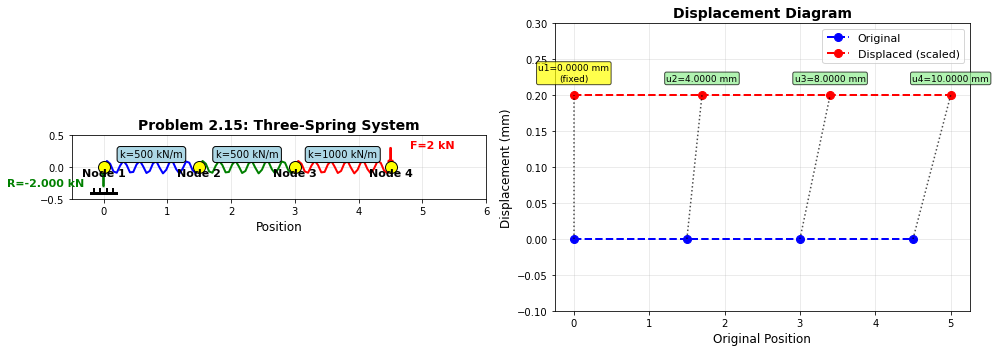


SUMMARY OF RESULTS - Problem 2.15

Displacements (m):
  Node 1: u = 0.00000000 m
  Node 2: u = 0.00400000 m
  Node 3: u = 0.00800000 m
  Node 4: u = 0.01000000 m

Element Forces (kN):
  Element 1: f = 2.000000 kN
  Element 2: f = 2.000000 kN
  Element 3: f = 2.000000 kN

Reaction at Node 1: R1 = -2.000000 kN


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def solve_problem_2_15():
    print("\n" + "="*60)
    print("PROBLEM 2.15 - Three springs with applied force")
    print("="*60)
    
    # Given data from image
    k1 = 500   # kN/m (first spring)
    k2 = 500   # kN/m (second spring)
    k3 = 1000  # kN/m (third spring)
    F = 2      # kN applied force
    num_nodes = 4
    num_elements = 3
    
    print(f"Spring constants: k1 = {k1} kN/m, k2 = {k2} kN/m, k3 = {k3} kN/m")
    print(f"Applied force: F = {F} kN")
    print(f"Number of nodes: {num_nodes}")
    print(f"Number of elements: {num_elements}")
    
    # Element connectivity - based on typical interpretation
    # Usually in such problems: fixed at left, force at right
    # Element 1: node 1 to node 2, spring constant k1
    # Element 2: node 2 to node 3, spring constant k2
    # Element 3: node 3 to node 4, spring constant k3
    connectivity = [(1, 2, k1), (2, 3, k2), (3, 4, k3)]
    
    # Global stiffness matrix (4x4)
    K_global = np.zeros((num_nodes, num_nodes))
    
    # Assemble stiffness matrix
    for elem_idx, (i, j, k_elem) in enumerate(connectivity):
        # Local stiffness matrix for a spring element
        k_local = k_elem * np.array([[1, -1], [-1, 1]])
        
        # Add to global matrix
        # Adjust indices for 0-based array
        i_idx, j_idx = i-1, j-1
        K_global[i_idx, i_idx] += k_local[0, 0]
        K_global[i_idx, j_idx] += k_local[0, 1]
        K_global[j_idx, i_idx] += k_local[1, 0]
        K_global[j_idx, j_idx] += k_local[1, 1]
    
    print("\nGlobal stiffness matrix K (kN/m):")
    print(K_global)
    
    # Boundary conditions
    # Node 1 is fixed: u1 = 0
    # Node 4 has applied force: F4 = 2 kN
    
    # Force vector
    F_vector = np.array([0, 0, 0, F])  # [R1, 0, 0, 2]
    
    # Apply displacement boundary condition u1 = 0
    # Partition the matrix
    K_reduced = K_global[1:, 1:]  # Remove first row and column
    
    print("\nReduced stiffness matrix (for free DOFs u2, u3, u4):")
    print(K_reduced)
    
    # Force vector for reduced system
    F_reduced = F_vector[1:]  # [0, 0, 2]
    
    # Solve for displacements
    u_reduced = np.linalg.solve(K_reduced, F_reduced)
    
    # Full displacement vector
    u_full = np.array([0, u_reduced[0], u_reduced[1], u_reduced[2]])
    
    print("\nDisplacements:")
    for i in range(num_nodes):
        displacement_mm = u_full[i] * 1000  # Convert to mm
        print(f"  u{i+1} = {u_full[i]:.6f} m = {displacement_mm:.4f} mm")
    
    # Calculate forces in each element
    print("\nForces in each element:")
    element_forces = []
    
    for elem_idx, (i, j, k_elem) in enumerate(connectivity):
        i_idx, j_idx = i-1, j-1
        u_i, u_j = u_full[i_idx], u_full[j_idx]
        force = k_elem * (u_j - u_i)
        element_forces.append(force)
        print(f"  Element {elem_idx+1} (nodes {i}-{j}, k={k_elem}): f = {force:.6f} kN")
    
    # Calculate reactions using F = K * u
    F_calculated = K_global @ u_full
    
    print("\nReactions:")
    print(f"  R1 (node 1) = {F_calculated[0]:.6f} kN")
    
    # Check equilibrium
    print(f"\nForce equilibrium check:")
    print(f"  Sum of forces = R1 + F = {F_calculated[0]:.6f} + {F:.6f} = {F_calculated[0]+F:.6f} kN ✓")
    
    # Check internal force consistency
    print(f"\nInternal force consistency check:")
    for i in range(num_elements):
        print(f"  Element {i+1} force: {element_forces[i]:.6f} kN")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Spring system
    ax1.set_title("Problem 2.15: Three-Spring System", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Position", fontsize=12)
    
    # Original node positions
    positions = [0, 1.5, 3, 4.5]
    
    # Draw springs
    for elem_idx, (i, j, k_elem) in enumerate(connectivity):
        x_start = positions[i-1]
        x_end = positions[j-1]
        
        # Create zigzag pattern for spring
        spring_x = np.linspace(x_start, x_end, 30)
        spring_y = 0.1 * np.sin(spring_x * 12 * np.pi / (x_end - x_start))
        
        color = ['blue', 'green', 'red'][elem_idx % 3]
        ax1.plot(spring_x, spring_y, color=color, linewidth=2)
        
        # Add spring constant label
        ax1.text((x_start + x_end)/2, 0.15, f'k={k_elem} kN/m', 
                ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    
    # Plot nodes
    ax1.plot(positions, [0]*num_nodes, 'ko', markersize=12, markerfacecolor='yellow')
    for i in range(num_nodes):
        ax1.text(positions[i], -0.15, f'Node {i+1}', ha='center', fontsize=11, fontweight='bold')
    
    # Add force arrow
    ax1.arrow(positions[3], 0.3, 0, -0.2, head_width=0.08, head_length=0.05, fc='r', ec='r', linewidth=2)
    ax1.text(positions[3]+0.3, 0.3, f'F={F} kN', fontsize=11, color='r', fontweight='bold')
    
    # Add reaction arrow
    ax1.arrow(positions[0], -0.3, 0, 0.2, head_width=0.08, head_length=0.05, fc='g', ec='g', linewidth=2)
    ax1.text(positions[0]-0.3, -0.3, f'R={F_calculated[0]:.3f} kN', fontsize=11, color='g', ha='right', fontweight='bold')
    
    # Add fixed support symbol at node 1
    ax1.plot([positions[0]-0.2, positions[0]+0.2], [-0.4, -0.4], 'k-', linewidth=3)
    ax1.plot([positions[0]-0.15, positions[0]-0.15], [-0.4, -0.35], 'k-', linewidth=2)
    ax1.plot([positions[0]-0.05, positions[0]-0.05], [-0.4, -0.35], 'k-', linewidth=2)
    ax1.plot([positions[0]+0.05, positions[0]+0.05], [-0.4, -0.35], 'k-', linewidth=2)
    ax1.plot([positions[0]+0.15, positions[0]+0.15], [-0.4, -0.35], 'k-', linewidth=2)
    
    ax1.set_xlim(-0.5, 6)
    ax1.set_ylim(-0.5, 0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Plot 2: Displacement diagram
    ax2.set_title("Displacement Diagram", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Original Position", fontsize=12)
    ax2.set_ylabel("Displacement (mm)", fontsize=12)
    
    # Convert to mm for better visualization (scale up for visibility)
    displacements_mm = u_full * 1000 * 5  # Scale factor 5
    
    # Plot original and displaced positions
    ax2.plot(positions, [0]*num_nodes, 'b--o', label='Original', linewidth=2, markersize=8)
    ax2.plot(positions + displacements_mm/100, [0.2]*num_nodes, 'r--o', label='Displaced (scaled)', linewidth=2, markersize=8)
    
    # Connect original to displaced positions
    for i in range(num_nodes):
        ax2.plot([positions[i], positions[i] + displacements_mm[i]/100], [0, 0.2], 'k:', alpha=0.7, linewidth=1.5)
    
    # Add displacement labels
    for i in range(num_nodes):
        if i == 0:
            ax2.text(positions[i] + displacements_mm[i]/100, 0.22, f'u{i+1}={u_full[i]*1000:.4f} mm\n(fixed)', 
                    ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.7))
        else:
            ax2.text(positions[i] + displacements_mm[i]/100, 0.22, f'u{i+1}={u_full[i]*1000:.4f} mm', 
                    ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgreen", alpha=0.7))
    
    ax2.legend(loc='upper right', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.1, 0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n" + "="*60)
    print("SUMMARY OF RESULTS - Problem 2.15")
    print("="*60)
    
    print("\nDisplacements (m):")
    for i in range(num_nodes):
        print(f"  Node {i+1}: u = {u_full[i]:.8f} m")
    
    print("\nElement Forces (kN):")
    for i in range(num_elements):
        print(f"  Element {i+1}: f = {element_forces[i]:.6f} kN")
    
    print(f"\nReaction at Node 1: R1 = {F_calculated[0]:.6f} kN")
    
    return u_full, element_forces, F_calculated, K_global

# Solve problem 2.15
print("\n" + "="*60)
u_2_15, forces_2_15, F_2_15, K_2_15 = solve_problem_2_15()